In [1]:
# II. Data Loading and Preprocessing
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


# Load dataset with a specific encoding
file_path = r'C:\Users\DELL\Desktop\FOLDERS\excel files\Bookk.csv'
try:
    data = pd.read_csv(file_path, encoding='latin1')
except UnicodeDecodeError:
    data = pd.read_csv(file_path, encoding='iso-8859-1')

In [3]:
data.describe()

,Concentration(%),Time(minute),Temperature(?),Recovery(%)
count,84.000000,84.000000,84.000000,84.000000
mean,0.212500,2.214286,133.333333,7.916667
std,0.189463,1.739488,41.342919,6.048416
min,0.000000,0.000000,80.000000,0.000000
25%,0.075000,0.500000,80.000000,0.000000
50%,0.175000,2.000000,140.000000,9.000000
75%,0.312500,4.000000,180.000000,14.000000
max,0.500000,5.000000,180.000000,16.000000


In [5]:
print(data.head())

   Concentration(%)   Time(minute)   Temperature(?)   Recovery(%) 
0               0.0             0.0              80              0
1               0.0             0.0             140              0
2               0.0             0.0             180              0
3               0.0             0.5              80              0
4               0.0             0.5             140              0


In [7]:
data.head(84)

,Concentration(%),Time(minute),Temperature(?),Recovery(%)
0,0.0,0.0,80,0
1,0.0,0.0,140,0
2,0.0,0.0,180,0
3,0.0,0.5,80,0
4,0.0,0.5,140,0
...,...,...,...,...
79,0.5,4.0,140,15
80,0.5,4.0,180,16
81,0.5,5.0,80,14
82,0.5,5.0,140,15


In [23]:
# Show summary information about the dataframe
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Concentration(%)  84 non-null     float64
 1    Time(minute)     84 non-null     float64
 2   Temperature(?)    84 non-null     int64  
 3    Recovery(%)      84 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 2.8 KB


In [53]:
data['Temperature(K)'] = data['Temperature(?)']
data = data.drop(columns ='Temperature(?)')


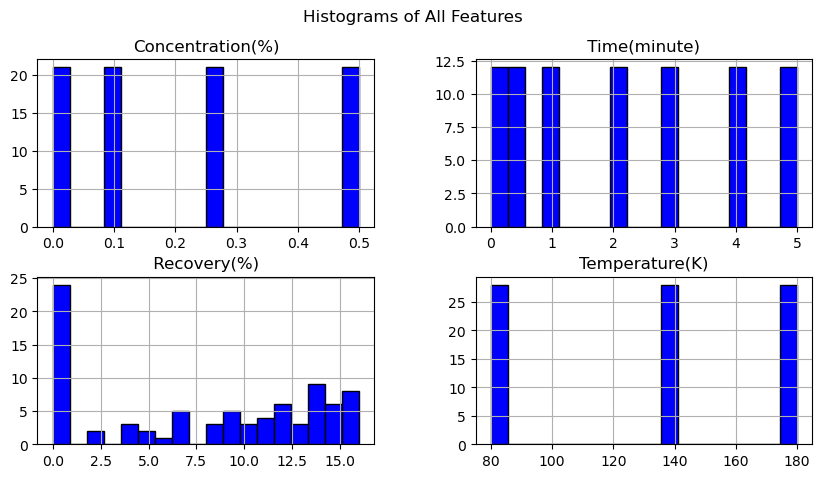

In [55]:
# Plotting histograms for all features
data.hist(bins=18, figsize=(10,5), color='blue', edgecolor='black')
plt.suptitle('Histograms of All Features', fontsize=12)
plt.show()

In [57]:
data.describe()


,Concentration(%),Time(minute),Recovery(%),Temperature(K)
count,84.000000,84.000000,84.000000,84.000000
mean,0.212500,2.214286,7.916667,133.333333
std,0.189463,1.739488,6.048416,41.342919
min,0.000000,0.000000,0.000000,80.000000
25%,0.075000,0.500000,0.000000,80.000000
50%,0.175000,2.000000,9.000000,140.000000
75%,0.312500,4.000000,14.000000,180.000000
max,0.500000,5.000000,16.000000,180.000000


In [61]:
data.shape

(84, 4)

In [63]:
print(data.columns.tolist())


['Concentration(%)', ' Time(minute) ', ' Recovery(%) ', 'Temperature(K)']


In [65]:
# Scatter plots of Flowing Bottomhole Pressure vs. all individual features
target =  ' Recovery(%) '
features = data.drop(columns=target).columns

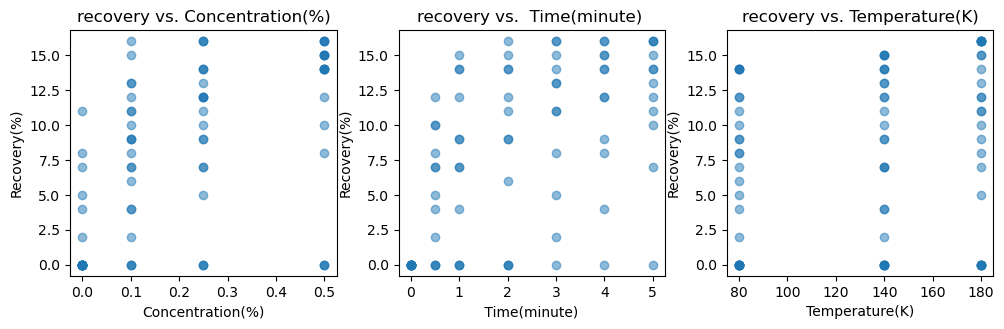

In [67]:
plt.figure(figsize=(10,6))
for i, feature in enumerate(features):
    plt.subplot(len(features) // 3 + 1, 3, i + 1)
    plt.scatter(data[feature], data[target], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('Recovery(%)')
    plt.title(f'recovery vs. {feature}')
plt.tight_layout()
plt.savefig('my_image.pdf')

plt.show()

In [10]:
# Rows with missing values
rows_with_missing = data[data.isnull().any(axis=1)]
print(rows_with_missing)

Empty DataFrame
Columns: [Concentration(%),  Time(minute) , Temperature(?),  Recovery(%) ]
Index: []


**No categorical data so skip this step**

In [12]:
# Remove duplicates
print("\nShape of dataset before removing duplicates:", data.shape)
data.drop_duplicates(inplace=True)
print("Shape of dataset after removing duplicates:", data.shape)


Shape of dataset before removing duplicates: (84, 4)
Shape of dataset after removing duplicates: (84, 4)


In [13]:
# Define Target and Features
target = ' Recovery(%) '
X_real = data[['Concentration(%)',  ' Time(minute) ' , 'Temperature(?)']]
y_real= data[target]

In [14]:
print(X_real.head())

   Concentration(%)   Time(minute)   Temperature(?)
0               0.0             0.0              80
1               0.0             0.0             140
2               0.0             0.0             180
3               0.0             0.5              80
4               0.0             0.5             140


In [15]:
# Convert y (pandas Series) to a NumPy array and reshape
y = y_real.values.reshape(-1, 1)

In [16]:
print(y_real)

0      0
1      0
2      0
3      0
4      0
      ..
79    15
80    16
81    14
82    15
83    16
Name:  Recovery(%) , Length: 84, dtype: int64


In [17]:
# Normalize or standardize numerical features
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X = scaler_x.fit_transform(X_real)
# Fit and transform the target variable (reshape it to 2D)
y = scaler_y.fit_transform(y_real.values.reshape(-1, 1))  # Reshape to 2D

In [18]:
X

array([[-1.12832963, -1.2805982 , -1.29777137],
       [-1.12832963, -1.2805982 ,  0.16222142],
       [-1.12832963, -1.2805982 ,  1.13554995],
       [-1.12832963, -0.99143086, -1.29777137],
       [-1.12832963, -0.99143086,  0.16222142],
       [-1.12832963, -0.99143086,  1.13554995],
       [-1.12832963, -0.70226353, -1.29777137],
       [-1.12832963, -0.70226353,  0.16222142],
       [-1.12832963, -0.70226353,  1.13554995],
       [-1.12832963, -0.12392886, -1.29777137],
       [-1.12832963, -0.12392886,  0.16222142],
       [-1.12832963, -0.12392886,  1.13554995],
       [-1.12832963,  0.45440581, -1.29777137],
       [-1.12832963,  0.45440581,  0.16222142],
       [-1.12832963,  0.45440581,  1.13554995],
       [-1.12832963,  1.03274048, -1.29777137],
       [-1.12832963,  1.03274048,  0.16222142],
       [-1.12832963,  1.03274048,  1.13554995],
       [-1.12832963,  1.61107515, -1.29777137],
       [-1.12832963,  1.61107515,  0.16222142],
       [-1.12832963,  1.61107515,  1.135

In [19]:
y

array([[-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-0.98409282],
       [-0.48511618],
       [-1.31674391],
       [-0.65144172],
       [ 0.01386046],
       [-1.31674391],
       [-0.15246508],
       [ 0.5128371 ],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-0.98409282],
       [-0.65144172],
       [-0.15246508],
       [-0.65144172],
       [-0.15246508],
       [ 0.18018601],
       [-0.31879063],
       [ 0.18018601],
       [ 0.5128371 ],
       [ 0.01386046],
       [ 0.5128371 ],
       [ 0.8454882 ],
       [ 0.18018601],
       [ 0.67916265],
       [ 1.17813929],
       [ 0.34651156],
       [ 0.8454882 ],
       [ 1.34446484],
       [-1.31674391],
       [-1.31674391],
       [-1.31674391],
       [-0

In [20]:
# Data Split: Split the dataset into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining and testing datasets created successfully.")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training and testing datasets created successfully.
Training data shape: (67, 3)
Testing data shape: (17, 3)


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

**ANN architecture**

In [24]:
from tensorflow.keras.layers import Dropout

ann_model = Sequential([
    Dense(128,input_shape=(X_train.shape[1],),activation='relu',),
    Dropout(0.1),  # Dropout layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

In [25]:
# Define early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

In [26]:
ann_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               512       
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 32)                4128      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 4,673
Trainable params: 4,673
Non-trainable params: 0
_________________________________________________________________


In [27]:
# Compile the model
ann_model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

In [28]:
# Train the model
history = ann_model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=20,
                    batch_size=32,
                    callbacks=[early_stopping],
                    verbose=1)

Epoch 1/20
3/3 [==============================] - 3s 278ms/step - loss: 1.1513 - mae: 0.9327 - val_loss: 1.3415 - val_mae: 1.0514
Epoch 2/20
3/3 [==============================] - 0s 42ms/step - loss: 1.1350 - mae: 0.9273 - val_loss: 1.3280 - val_mae: 1.0460
Epoch 3/20
3/3 [==============================] - 0s 46ms/step - loss: 1.0410 - mae: 0.8899 - val_loss: 1.3159 - val_mae: 1.0409
Epoch 4/20
3/3 [==============================] - 0s 40ms/step - loss: 1.0958 - mae: 0.9124 - val_loss: 1.3040 - val_mae: 1.0359
Epoch 5/20
3/3 [==============================] - 0s 48ms/step - loss: 1.0895 - mae: 0.9017 - val_loss: 1.2928 - val_mae: 1.0310
Epoch 6/20
3/3 [==============================] - 0s 37ms/step - loss: 1.0703 - mae: 0.8993 - val_loss: 1.2825 - val_mae: 1.0263
Epoch 7/20
3/3 [==============================] - 0s 42ms/step - loss: 1.0565 - mae: 0.8989 - val_loss: 1.2722 - val_mae: 1.0217
Epoch 8/20
3/3 [==============================] - 0s 49ms/step - loss: 1.0321 - mae: 0.8622 - va

In [29]:
# Evaluate the model
nn_loss, ann_mae = ann_model.evaluate(X_test, y_test, verbose=0)
y_pred_ann = ann_model.predict(X_test)

1/1 [==============================] - 0s 250ms/step


In [30]:
# Calculate R2 score
from sklearn.metrics import r2_score
ann_R2= r2_score(y_test, y_pred_ann)
print(f"R2 Score: {ann_R2}")

R2 Score: -0.024034843340502654


In [31]:
# Calculate R2 score
from sklearn.metrics import r2_score
ann_r2 = r2_score(y_test, y_pred_ann)
print(f"R2 Score: {ann_R2}")

R2 Score: -0.024034843340502654


In [32]:
print(f'ANN Mean Absolute Error: {ann_mae:.4f}')
print(f'ANN Mean Squared Error: {mean_squared_error(y_test, y_pred_ann):.4f}')
print(f'ANN R-squared: {ann_R2:.4f}')

ANN Mean Absolute Error: 0.9638
ANN Mean Squared Error: 1.1430
ANN R-squared: -0.0240


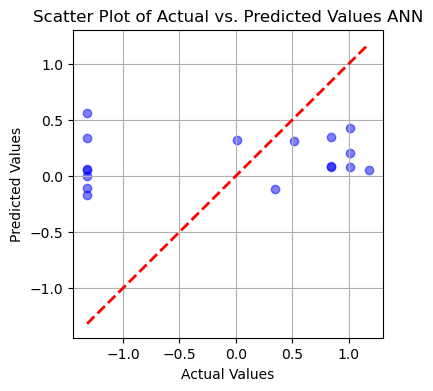

In [33]:
# Plotting the scatter plot
plt.figure(figsize=(4,4))
plt.scatter(y_test, y_pred_ann, c='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2)  # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of Actual vs. Predicted Values ANN')
plt.grid(True)
plt.show()

In [34]:
# Save the model in the current working directory
ann_model.save('custom_ann_modeluchemainann.keras')

**SVM**

In [36]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [37]:

# Initialize the SVR model with RBF kernel
svr_model = SVR(kernel='rbf', gamma='scale', C=1.0)
y_train = y_train.ravel()
y_test = y_test.ravel()

# Train the model
svr_model.fit(X_train, y_train)


SVR()

In [38]:
# Predict the values for the test set
y_pred_svm = svr_model.predict(X_test)

In [39]:
# Evaluate the model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_svm))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_svm))
print("R^2 Score:", r2_score(y_test, y_pred))


Mean Squared Error: 0.32101122736510485
Mean Absolute Error: 0.402803625299949


NameError: name 'y_pred' is not defined

In [ ]:
# Plotting the scatter plot
plt.figure(figsize=(4,4))
plt.scatter(y_test,y_pred_svm, c='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=2)  # Diagonal line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Scatter Plot of Actual vs. Predicted Values SVM')
plt.grid(True)
plt.show()

**Random forest**

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf.fit(X_train, y_train.ravel())




RandomForestRegressor(random_state=42)

In [47]:

y_pred = rf.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")

MAE: 0.14313780876198606
MSE: 0.056001591142810496
R²: 0.9498256518010292


In [49]:
import joblib

# Save the model to a file
joblib.dump(rf, 'random_forest_modeluche.pkl')

['random_forest_modeluche.pkl']

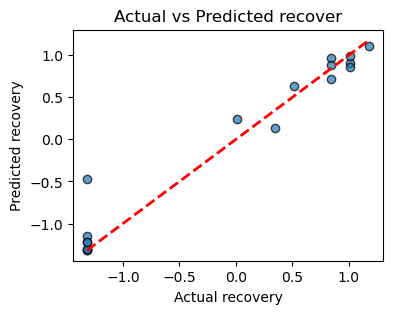

In [50]:
import matplotlib.pyplot as plt

# Plotting actual vs predicted values
plt.figure(figsize=(4, 3))
plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel('Actual recovery')
plt.ylabel('Predicted recovery')
plt.title('Actual vs Predicted recover')
plt.savefig('actual_vs_predicted2.png')
plt.show()

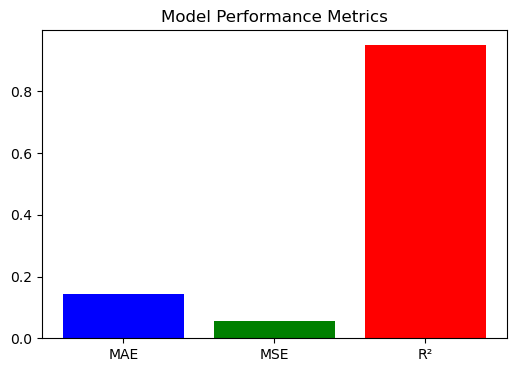

In [51]:
metrics = {
    'MAE': mae,
    'MSE': mse,
    'R²': r2
}

plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color=['blue', 'green', 'red'])
plt.title('Model Performance Metrics')
plt.savefig('metrics_plot.png')
plt.show()

**DecisionTree**

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the model
dt = DecisionTreeRegressor(random_state=42)

# Train the model
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [63]:
y_pred = dt.predict(X_test)

In [65]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")

MAE: 0.15654169105890514
MSE: 0.1008929191239028
R²: 0.9096054888507719


In [67]:
import joblib

# Save the model to a file
joblib.dump(dt, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

In [69]:
# Load the model from a file
dt = joblib.load('decision_tree_model.pkl')

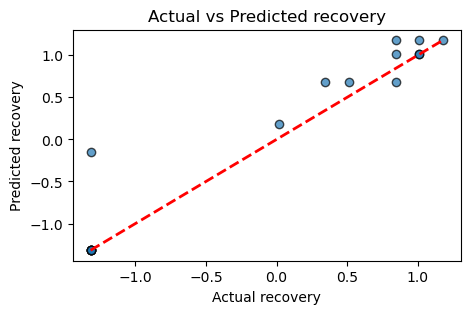

In [71]:
import matplotlib.pyplot as plt

# Plotting actual vs predicted values
plt.figure(figsize=(5, 3))
plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel('Actual recovery')
plt.ylabel('Predicted recovery')
plt.title('Actual vs Predicted recovery')
plt.show()

**THANK YOU**